# Testing the draft impulse plot (`new_graphics/impluse.py`)

This notebook exercises `make_impulse()` and `overlay_true_distribution()`, the draft
implementation of the new impulse plot type from the approved Task 1E prototype. It is
**not** wired into `.plot()` yet — this is for visually checking the draft before
integration.

**How to run:** use the `symbulate` conda environment (the draft imports helpers from
`symbulate.plot`, which is only installed there), then Run All. The setup cell finds the
repo root on its own, so it doesn't matter which folder Jupyter was launched from — and
it reloads `impluse.py` every time it runs, so after editing the draft just Run All
again; no kernel restart needed. Its printout shows which constants are loaded, so you
can confirm the kernel matches the file.

**What to look for in every plot:**
- Bold stems (line width 2.2) capped with a filled circle at each frequency
- Light horizontal reference grid, drawn *behind* the stems; no top or right spines
- x-axis labeled "Value"; y-axis "Relative Frequency" (or "Count" when `normalize=False`)
- Overlays get distinct Okabe-Ito colors (sky blue first, then orange) and an automatic
  "Variable k" legend in the top right; the group of stems straddles each value
  symmetrically, so no stem hides another and each stem clearly belongs to its value
- The true pmf overlay reads as a reference layer: a smooth curve with no markers

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Locate the repo root (the folder holding symbulate/symbulate.mplstyle),
# so the notebook works no matter where Jupyter was launched from.
REPO_ROOT = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "symbulate" / "symbulate.mplstyle").exists()
)
sys.path.insert(0, str(REPO_ROOT / "team" / "new_graphics"))

# The draft helpers and their per-plot-type constants. The reload makes
# re-running this cell pick up the latest impluse.py even in a kernel
# that already imported an older version -- no kernel restart needed
# while the draft is being iterated on.
import impluse

importlib.reload(impluse)
from impluse import (
    make_impulse,
    overlay_true_distribution,
    IMPULSE_LINEWIDTH,
    IMPULSE_ALPHA,
    IMPULSE_SERIES_OFFSET,
)
from symbulate.plot import get_next_color

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# Applied *after* the imports above: importing symbulate currently switches
# matplotlib back to the old seaborn/ggplot stylesheet (a Phase 2 item).
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(
    f"IMPULSE_LINEWIDTH = {IMPULSE_LINEWIDTH}, IMPULSE_ALPHA = {IMPULSE_ALPHA}, "
    f"IMPULSE_SERIES_OFFSET = {IMPULSE_SERIES_OFFSET}"
)

IMPULSE_LINEWIDTH = 2.2, IMPULSE_ALPHA = 1.0, IMPULSE_SERIES_OFFSET = 0.35


## 1. Reproduce the approved prototype

Two overlaid Poisson-ish variables, matching the prototype image: Variable 1
peaking around 3, Variable 2 peaking around 5, "Variable k" legend in the top
right. In the final integration each `.plot()` call takes its color from
`get_next_color(ax)`, so we do the same here — the cycle gives sky blue
(`#56B4E9`) first, then orange (`#E69F00`). The pair of stems should straddle
each value symmetrically — sky blue just left of the tick, orange just right —
so neither hides the other and both clearly belong to their value.

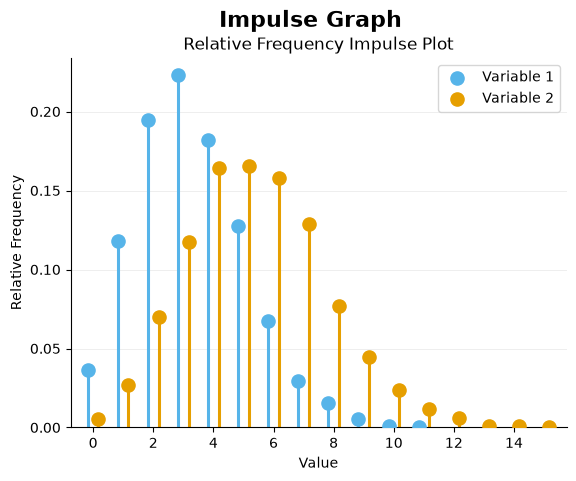

In [2]:
sample_a = rng.poisson(3.3, 5000)
sample_b = rng.poisson(5.3, 5000)

ax = plt.gca()
make_impulse(sample_a, ax, get_next_color(ax))
make_impulse(sample_b, ax, get_next_color(ax))
plt.show()

## 2. Options: counts, transparency, custom labels

`normalize=False` should switch the y-axis to "Count" and the subtitle to
"Count Impulse Plot".

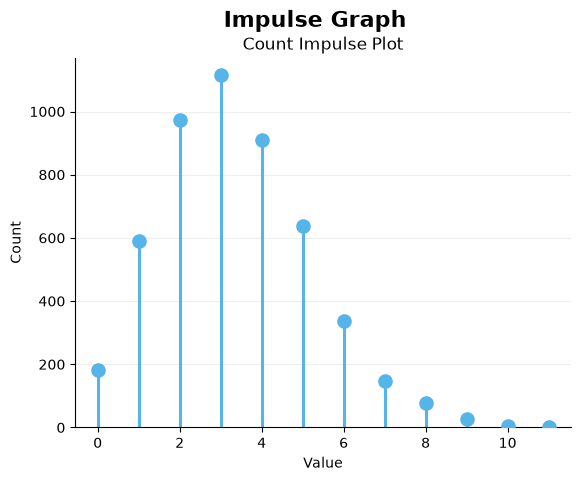

In [3]:
ax = plt.gca()
make_impulse(sample_a, ax, get_next_color(ax), normalize=False)
plt.show()

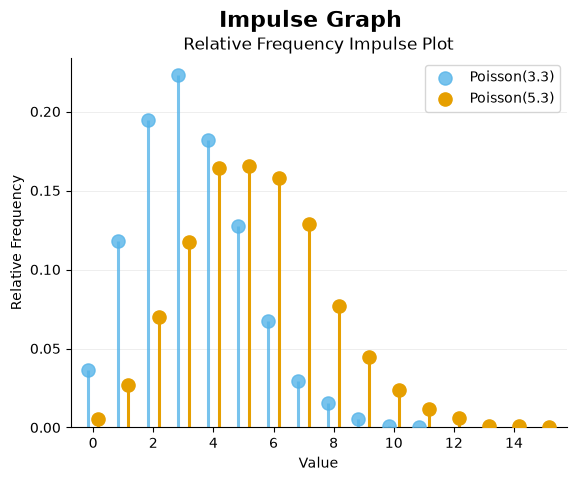

In [4]:
# Custom labels replace the automatic "Variable k" names. The symmetric
# straddle around each value is automatic (IMPULSE_SERIES_OFFSET);
# jitter=True adds random noise on top if even more separation is needed.
ax = plt.gca()
make_impulse(sample_a, ax, get_next_color(ax), label="Poisson(3.3)", alpha=0.8)
make_impulse(sample_b, ax, get_next_color(ax), label="Poisson(5.3)")
plt.show()

## 3. With real symbulate simulation data

Same draft, but the data comes from an actual `RV(...).sim(...)` call instead
of raw numpy.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

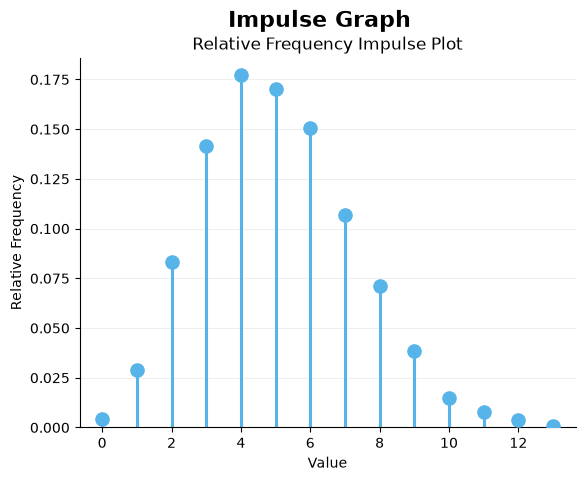

In [5]:
from symbulate import RV, Poisson

sims = RV(Poisson(5)).sim(3000)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_impulse(np.asarray(sims.results), ax, get_next_color(ax))
plt.show()

## 4. The classic teaching use case: true pmf over the simulated impulses

`overlay_true_distribution()` draws the exact probability mass as a smooth,
marker-free curve through the pmf values — visually distinct from the bold,
circle-capped simulated stems, the way a density curve reads over a histogram.
Distribution objects already expose the exact pmf as a vectorized callable
(`Poisson(5).pmf`), so it plugs straight in. With no `xlim=` given, the overlay
reads the integer range off the axes the impulse plot just configured, and with
no `color=` it advances the color cycle itself.

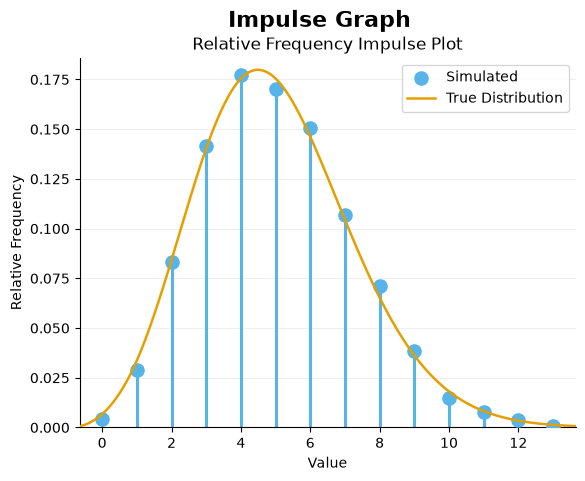

In [6]:
ax = plt.gca()
make_impulse(np.asarray(sims.results), ax, get_next_color(ax), label="Simulated")
overlay_true_distribution(Poisson(5).pmf, ax)
plt.show()

## Verification checklist

- [ ] Section 1 matches the approved prototype image (sky blue + orange, legend upper right)
- [ ] Stems are bold and capped with filled circles; grid behind; no top/right spines
- [ ] Overlaid stems straddle each value symmetrically — none hidden, none floating between values
- [ ] `normalize=False` shows "Count" on the y-axis and the "Count Impulse Plot" subtitle
- [ ] Custom `label=` and `alpha=` overrides work
- [ ] Works on real `.sim()` output, not just numpy arrays
- [ ] True pmf overlay: a smooth marker-free curve, clearly distinct from the simulated stems
- [ ] Legend appears automatically once a second series (variable or true pmf) is added